"""
Notebook 04 — High-Resolution Landmark Visualizations
Author: Armando de Jesús Becerril Carrillo
Purpose:
- Generate 600 dpi figures for the manuscript (temporal trajectories + landmark overlays)
- Provide reproducible visualization scripts for the MSL-150 dataset
- Support representative MSL gestures
"""

# 1. Introduction

Purpose of notebook

Use cases (paper figures, reproducibility, dataset documentation)

In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Si usas Jupyter clásico:
%matplotlib inline

# Configuración global de estilo para las figuras (pensando en revista)
plt.rcParams.update({
    "figure.dpi": 100,          # dpi base en notebook (luego exportamos a 600)
    "savefig.dpi": 600,         # dpi para los archivos guardados
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Ruta para guardar todas las figuras
FIG_DIR = Path("../docs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)   # crea si no existe
print("Saving figures to:", FIG_DIR)
print("Environment ready.")

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

import mediapipe as mp

DATA_ROOT = Path("../data/original_source").resolve()
print("DATA_ROOT:", DATA_ROOT)

In [ ]:
video_files = sorted(list(DATA_ROOT.rglob("*.mp4")))
print("Videos encontrados:", len(video_files))
for v in video_files:
    print(v.name)

In [ ]:
SIGN_KEYWORD = "doctor"   # cámbialo a 'hoy', 'dolor', etc.

candidates = [v for v in video_files if SIGN_KEYWORD.lower() in v.name.lower()]
if not candidates:
    raise ValueError(f"No se encontraron videos que contengan '{SIGN_KEYWORD}'")

video_path = candidates[0]
print("Usando video:", video_path.name)

In [ ]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# Configuración estándar (igual/compatible con tu pipeline principal)
holistic = mp_holistic.Holistic(
    static_image_mode=False,
    model_complexity=2,
    smooth_landmarks=True,
    enable_segmentation=False,
    refine_face_landmarks=False
)


In [ ]:
from dataclasses import dataclass

@dataclass
class WristTrajectories:
    frames: np.ndarray
    left_wrist: np.ndarray   # shape (T, 3)
    right_wrist: np.ndarray  # shape (T, 3)


def extract_wrist_trajectories(video_path, max_frames=None):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    lwrist = []
    rwrist = []

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if max_frames is not None and frame_idx > max_frames:
            break

        # MediaPipe usa RGB
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(img_rgb)

        if results.pose_landmarks:
            # 15 = left_wrist, 16 = right_wrist en MediaPipe Holistic Pose
            l = results.pose_landmarks.landmark[15]
            r = results.pose_landmarks.landmark[16]
            lwrist.append([l.x, l.y, l.z])
            rwrist.append([r.x, r.y, r.z])
            frames.append(frame_idx)

    cap.release()

    if not frames:
        raise RuntimeError("No se detectaron landmarks de pose en el video.")

    return WristTrajectories(
        frames=np.array(frames),
        left_wrist=np.array(lwrist),
        right_wrist=np.array(rwrist)
    )


In [ ]:
traj = extract_wrist_trajectories(video_path)

plt.figure(figsize=(10, 4))
plt.title(f"Word: {SIGN_KEYWORD.capitalize()}", fontsize=16)

# Left wrist
plt.plot(traj.frames, traj.left_wrist[:, 0], "o-", label="Left wrist x")
plt.plot(traj.frames, traj.left_wrist[:, 1], "o-", label="Left wrist y")
plt.plot(traj.frames, traj.left_wrist[:, 2], "o-", label="Left wrist z")

# Right wrist
plt.plot(traj.frames, traj.right_wrist[:, 0], "x--", label="Right wrist x")
plt.plot(traj.frames, traj.right_wrist[:, 1], "x--", label="Right wrist y")
plt.plot(traj.frames, traj.right_wrist[:, 2], "x--", label="Right wrist z")

plt.xlabel("Frame")
plt.ylabel("Values (normalized)")
plt.grid(True, alpha=0.4)
plt.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 2
mp_holistic = mp.solutions.holistic

def extract_wrist_series_and_frame(video_path, target_frame_idx=None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if target_frame_idx is None:
        target_frame_idx = n_frames // 2   # frame de en medio

    left_wrist = []
    right_wrist = []
    selected_frame = None
    selected_landmarks = None

    with mp_holistic.Holistic(static_image_mode=False,
                              model_complexity=2,
                              enable_segmentation=False) as holistic:

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            # Pose landmarks (muñecas: 15 = left_wrist, 16 = right_wrist en MediaPipe)
            if results.pose_world_landmarks:
                lw = results.pose_world_landmarks.landmark[15]
                rw = results.pose_world_landmarks.landmark[16]
                left_wrist.append((lw.x, lw.y, lw.z))
                right_wrist.append((rw.x, rw.y, rw.z))
            else:
                left_wrist.append((np.nan, np.nan, np.nan))
                right_wrist.append((np.nan, np.nan, np.nan))

            # guardamos un frame para visualizar
            if frame_idx == target_frame_idx:
                selected_frame = frame.copy()
                selected_landmarks = results

            frame_idx += 1

    cap.release()

    left_wrist = np.array(left_wrist)
    right_wrist = np.array(right_wrist)

    return left_wrist, right_wrist, selected_frame, selected_landmarks


In [ ]:
# Cell 3
mp_drawing = mp.solutions.drawing_utils

def draw_landmarks_on_frame(frame_bgr, results):
    """Devuelve una imagen RGB con pose y manos dibujadas."""
    img = frame_bgr.copy()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            img_rgb,
            results.pose_landmarks,
            mp_holistic.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing.DrawingSpec(thickness=2, circle_radius=2),
            connection_drawing_spec=mp_drawing.DrawingSpec(thickness=2))
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            img_rgb,
            results.left_hand_landmarks,
            mp.solutions.hands.HAND_CONNECTIONS,
            landmark_drawing_spec=mp_drawing.DrawingSpec(thickness=2, circle_radius=2),
            connection_drawing_spec=mp_drawing.DrawingSpec(thickness=2))
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            img_rgb,
            results.right_hand_landmarks,
            mp.solutions.hands.HAND_CONNECTIONS,
            landmark_drawing_spec=mp_drawing.DrawingSpec(thickness=2, circle_radius=2),
            connection_drawing_spec=mp_drawing.DrawingSpec(thickness=2))

    return img_rgb


In [ ]:
# Cell 4
def plot_wrist_time_series_with_frame(video_path, word_label="Word"):
    left_wrist, right_wrist, frame_bgr, results = extract_wrist_series_and_frame(video_path)

    # Normalizamos (opcional, para estética)
    all_vals = np.vstack([left_wrist, right_wrist])
    mean = np.nanmean(all_vals, axis=0)
    std = np.nanstd(all_vals, axis=0) + 1e-8
    lw_norm = (left_wrist - mean) / std
    rw_norm = (right_wrist - mean) / std

    frames = np.arange(len(lw_norm))

    fig, (ax_ts, ax_img) = plt.subplots(
        1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 2]}
    )

    # ---- Subplot 1: serie temporal
    ax_ts.plot(frames, lw_norm[:, 0], marker='o', linestyle='-', label='Left wrist x')
    ax_ts.plot(frames, lw_norm[:, 1], marker='o', linestyle='-', label='Left wrist y')
    ax_ts.plot(frames, lw_norm[:, 2], marker='o', linestyle='-', label='Left wrist z')

    ax_ts.plot(frames, rw_norm[:, 0], marker='x', linestyle='--', label='Right wrist x')
    ax_ts.plot(frames, rw_norm[:, 1], marker='x', linestyle='--', label='Right wrist y')
    ax_ts.plot(frames, rw_norm[:, 2], marker='x', linestyle='--', label='Right wrist z')

    ax_ts.set_title(f"Wrist Landmark Dynamics for the Sign “{word_label}”")
    ax_ts.set_xlabel("Frame")
    ax_ts.set_ylabel("Values (normalized)")
    ax_ts.grid(True, alpha=0.3)
    ax_ts.legend(loc="upper right", fontsize=8)

    # ---- Subplot 2: frame con landmarks
    if frame_bgr is not None and results is not None:
        img_rgb = draw_landmarks_on_frame(frame_bgr, results)
        ax_img.imshow(img_rgb)
        ax_img.axis("off")
        ax_img.set_title("Example Pose & Hand Landmarks (MediaPipe Holistic)")

    plt.tight_layout()
    plt.show()

    fig.savefig("doctor_wrist_landmarks.png", dpi=600, bbox_inches="tight")
    fig.savefig("doctor_wrist_landmarks.pdf", bbox_inches="tight")



In [ ]:
# Cell 5
DATA_ROOT = Path("../data/original_source").resolve()
video_path = next(DATA_ROOT.rglob("*doctor*_001.mp4"))  # ajusta al nombre real
print(video_path)

plot_wrist_time_series_with_frame(video_path, word_label="Doctor")


In [ ]:
def extract_wrist_series_and_frames_2(video_path, frame_indices):
    """
    Recorre el video y devuelve:
      - arrays con la serie temporal de las muñecas (x,y,z)
      - diccionario frame_index -> imagen RGB anotada con landmarks
    """
    cap = cv2.VideoCapture(str(video_path))

    left_x, left_y, left_z = [], [], []
    right_x, right_y, right_z = [], [], []

    frames_for_imgs = {}
    frame_id = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=2,
        enable_segmentation=False,
        refine_face_landmarks=False
    ) as holistic:

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            results = holistic.process(frame_rgb)

            # Muñeca mano izquierda
            if results.left_hand_landmarks:
                lw = results.left_hand_landmarks.landmark[0]  # wrist
                left_x.append(lw.x)
                left_y.append(lw.y)
                left_z.append(lw.z)
            else:
                left_x.append(np.nan)
                left_y.append(np.nan)
                left_z.append(np.nan)

            # Muñeca mano derecha
            if results.right_hand_landmarks:
                rw = results.right_hand_landmarks.landmark[0]
                right_x.append(rw.x)
                right_y.append(rw.y)
                right_z.append(rw.z)
            else:
                right_x.append(np.nan)
                right_y.append(np.nan)
                right_z.append(np.nan)

            # Guardamos imagen anotada solo para los frames de interés
            if frame_id in frame_indices:
                annotated = frame_bgr.copy()
                mp_drawing.draw_landmarks(
                    annotated,
                    results.pose_landmarks,
                    mp_holistic.POSE_CONNECTIONS
                )
                mp_drawing.draw_landmarks(
                    annotated,
                    results.left_hand_landmarks,
                    mp_holistic.HAND_CONNECTIONS
                )
                mp_drawing.draw_landmarks(
                    annotated,
                    results.right_hand_landmarks,
                    mp_holistic.HAND_CONNECTIONS
                )
                frames_for_imgs[frame_id] = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

            frame_id += 1

    cap.release()

    series = {
        "left_x":  np.array(left_x),
        "left_y":  np.array(left_y),
        "left_z":  np.array(left_z),
        "right_x": np.array(right_x),
        "right_y": np.array(right_y),
        "right_z": np.array(right_z),
    }

    return series, frames_for_imgs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_series_with_single_frame(series, frame_img, frame_index,
                                  word="Doctor", save_prefix="doctor_frame",
                                  out_dir=FIG_DIR):
    """
    Genera una figura con:
      - Izquierda: serie de muñecas (x,y,z) SOLO hasta frame_index.
      - Derecha: imagen con pose + manos del frame correspondiente.

    Guarda PDF (para Overleaf) y PNG (600 dpi) en out_dir.
    """
    # --- usamos datos SOLO hasta frame_index ---
    max_idx = int(frame_index)
    # cuidado por si frame_index == último índice
    t = np.arange(max_idx + 1)

    def zscore(x):
        x = np.asarray(x)
        x = x[:max_idx + 1]
        m = np.nanmean(x)
        s = np.nanstd(x)
        return (x - m) / s if s > 0 else x - m

    left_x  = zscore(series["left_x"])
    left_y  = zscore(series["left_y"])
    left_z  = zscore(series["left_z"])
    right_x = zscore(series["right_x"])
    right_y = zscore(series["right_y"])
    right_z = zscore(series["right_z"])

    fig, (ax_ts, ax_img) = plt.subplots(1, 2, figsize=(12, 4))

    # --- Gráfica de series (hasta frame_index) ---
    ax_ts.plot(t, left_x,  label="Left wrist x",  marker="o", markersize=2, linewidth=1)
    ax_ts.plot(t, left_y,  label="Left wrist y",  marker="o", markersize=2, linewidth=1)
    ax_ts.plot(t, left_z,  label="Left wrist z",  marker="o", markersize=2, linewidth=1)

    ax_ts.plot(t, right_x, label="Right wrist x", marker="x", markersize=2, linewidth=1, linestyle="--")
    ax_ts.plot(t, right_y, label="Right wrist y", marker="x", markersize=2, linewidth=1, linestyle="--")
    ax_ts.plot(t, right_z, label="Right wrist z", marker="x", markersize=2, linewidth=1, linestyle="--")

    ax_ts.set_xlabel("Frame")
    ax_ts.set_ylabel("Values (normalized)")
    ax_ts.set_title(f'Wrist Landmark Dynamics for the Sign "{word}"\n(up to frame {frame_index})')
    ax_ts.grid(True, linestyle=":", linewidth=0.5)
    ax_ts.legend(loc="upper right", fontsize=8)

    # --- Imagen del frame ---
    if frame_img is not None:
        ax_img.imshow(frame_img)
    ax_img.axis("off")
    ax_img.set_title(f"Pose & Hand Landmarks (frame {frame_index})", fontsize=10)

    fig.tight_layout()

    # Construimos ruta de salida en docs/figures
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = out_dir / f"{save_prefix}_{frame_index}.pdf"
    png_path = out_dir / f"{save_prefix}_{frame_index}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", pdf_path)
    print("Saved:", png_path)



In [ ]:
from pathlib import Path

# Ruta de tu video
DATA_ROOT = Path("../data/original_source").resolve()
video_path = next(DATA_ROOT.rglob("*doctor*_001.mp4"))
print("Using video:", video_path)

# Frames que quieres “imprimir”
frame_indices = [15, 30, 45, 60]

# 1) Extraer series + imágenes
series, frames_for_imgs = extract_wrist_series_and_frames_2(video_path, frame_indices)

# 2) Generar una figura por frame
for fi in frame_indices:
    img = frames_for_imgs.get(fi, None)
    plot_series_with_single_frame(
        series=series,
        frame_img=img,
        frame_index=fi,
        word="Doctor",
        save_prefix="fig_doctor_wrist",
        out_dir=FIG_DIR          # 👈 ahora se van a docs/figures
    )

Using video: /Users/armandobecerril/PhD/MSL-150/data/original_source/ambulancia_001.mp4


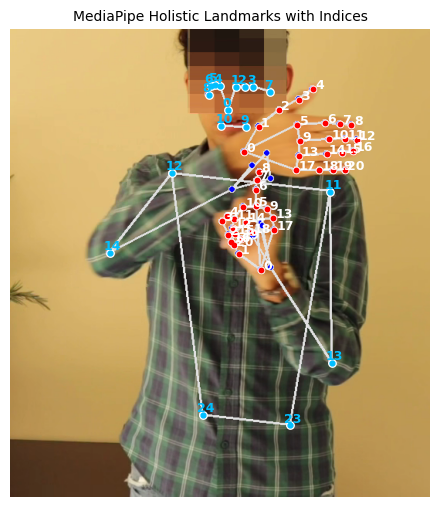

Saved: ../docs/figures/mediapipe_landmark_index_map.pdf
Saved: ../docs/figures/mediapipe_landmark_index_map.png


In [2]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# --- Rutas ---
DATA_ROOT = Path("../data/original_source").resolve()
OUT_DIR = Path("../docs/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Elige el video de referencia
video_path = next(DATA_ROOT.rglob("*ambulancia*_001.mp4"))
print("Using video:", video_path)

# --- Extraer un frame representativo (mitad del video) ---
cap = cv2.VideoCapture(str(video_path))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
target_frame = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError("No se pudo leer el frame seleccionado")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# --- Ejecutar MediaPipe Holistic ---
with mp_holistic.Holistic(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    refine_face_landmarks=False
) as holistic:
    results = holistic.process(frame_rgb)

annotated = frame_rgb.copy()

# Dibuja pose + manos (solo esqueleto base)
if results.pose_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS
    )
if results.left_hand_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )
if results.right_hand_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

h, w, _ = annotated.shape

# ========= ZOOM AUTOMÁTICO SOBRE LA PERSONA =========
if results.pose_landmarks:
    xs = [lm.x * w for lm in results.pose_landmarks.landmark]
    ys = [lm.y * h for lm in results.pose_landmarks.landmark]

    margin_x = 0.10 * w
    margin_y = 0.10 * h

    x_min = max(0, int(min(xs) - margin_x))
    x_max = min(w, int(max(xs) + margin_x))
    y_min = max(0, int(min(ys) - margin_y))
    y_max = min(h, int(max(ys) + margin_y))

    annotated_cropped = annotated[y_min:y_max, x_min:x_max].copy()
else:
    annotated_cropped = annotated.copy()

hc, wc, _ = annotated_cropped.shape

# --- Lista de índices de pose a mostrar (sin 15,16 para no duplicar wrists) ---
selected_pose_ids = [
    0,          # nose
    11, 12,     # shoulders
    13, 14,     # elbows
    # 15, 16,   # wrists -> los quitamos para que solo se vean como mano
    23, 24,     # hips
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10
]

# ========= FIGURA CON PUNTOS + ÍNDICES =========
fig, ax = plt.subplots(figsize=(4.5, 7))
ax.imshow(annotated_cropped)
ax.axis("off")

# --- Pose con halo blanco e índices arriba-izquierda ---
if results.pose_landmarks:
    for idx, lm in enumerate(results.pose_landmarks.landmark):
        if idx not in selected_pose_ids:
            continue
        x = lm.x * w - x_min
        y = lm.y * h - y_min

        # halo blanco
        ax.scatter(x, y, s=28, c="white", zorder=2)
        # punto azul
        ax.scatter(x, y, s=12, c="deepskyblue", zorder=3)

        # texto arriba-izquierda para no encimar manos
        text_x = x - 8
        text_y = y - 4
        ax.text(
            text_x, text_y,
            str(idx),
            color="deepskyblue",
            fontsize=9,
            weight="bold",
            zorder=4
        )

# --- Manos con halo blanco + texto blanco ---
def label_hand(hand_landmarks, point_color, text_color):
    if not hand_landmarks:
        return
    for idx, lm in enumerate(hand_landmarks.landmark):
        x = lm.x * w - x_min
        y = lm.y * h - y_min

        # halo blanco
        ax.scatter(x, y, s=20, c="white", zorder=2)
        # punto de color
        ax.scatter(x, y, s=10, c=point_color, zorder=3)

        ax.text(
            x + 3, y,
            str(idx),
            color=text_color,
            fontsize=9,
            weight="bold",
            zorder=4,
        )

# Mano izquierda y derecha en rojo con texto blanco (bien contrastado)
label_hand(results.left_hand_landmarks,  point_color="red", text_color="white")
label_hand(results.right_hand_landmarks, point_color="red", text_color="white")

ax.set_title("MediaPipe Holistic Landmarks with Indices", fontsize=10)
fig.tight_layout()

pdf_path = OUT_DIR / "mediapipe_landmark_index_map.pdf"
png_path = OUT_DIR / "mediapipe_landmark_index_map.png"

fig.savefig(pdf_path, dpi=600, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", pdf_path)
print("Saved:", png_path)


Using video: /Users/armandobecerril/PhD/MSL-150/data/original_source/ambulancia_001.mp4


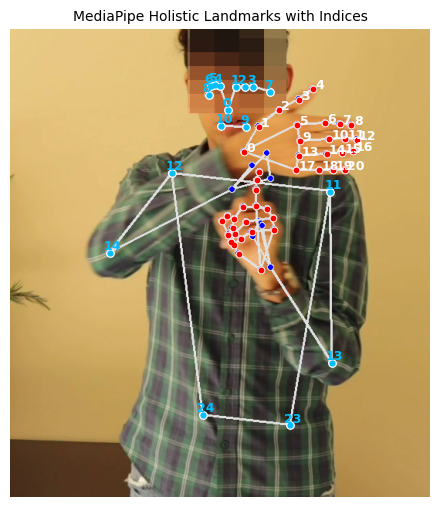

Saved: ../docs/figures/mediapipe_landmark_index_map.pdf
Saved: ../docs/figures/mediapipe_landmark_index_map.png


In [3]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# --- Rutas ---
DATA_ROOT = Path("../data/original_source").resolve()
OUT_DIR = Path("../docs/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Elige el video de referencia
video_path = next(DATA_ROOT.rglob("*ambulancia*_001.mp4"))
print("Using video:", video_path)

# --- Extraer un frame representativo (mitad del video) ---
cap = cv2.VideoCapture(str(video_path))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
target_frame = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError("No se pudo leer el frame seleccionado")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# --- Ejecutar MediaPipe Holistic ---
with mp_holistic.Holistic(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    refine_face_landmarks=False
) as holistic:
    results = holistic.process(frame_rgb)

annotated = frame_rgb.copy()

# Dibuja pose + manos (solo esqueleto base)
if results.pose_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS
    )
if results.left_hand_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )
if results.right_hand_landmarks:
    mp_drawing.draw_landmarks(
        annotated,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

h, w, _ = annotated.shape

# ========= ZOOM AUTOMÁTICO SOBRE LA PERSONA =========
if results.pose_landmarks:
    xs = [lm.x * w for lm in results.pose_landmarks.landmark]
    ys = [lm.y * h for lm in results.pose_landmarks.landmark]

    margin_x = 0.10 * w
    margin_y = 0.10 * h

    x_min = max(0, int(min(xs) - margin_x))
    x_max = min(w, int(max(xs) + margin_x))
    y_min = max(0, int(min(ys) - margin_y))
    y_max = min(h, int(max(ys) + margin_y))

    annotated_cropped = annotated[y_min:y_max, x_min:x_max].copy()
else:
    annotated_cropped = annotated.copy()

hc, wc, _ = annotated_cropped.shape

# --- Índices de pose (sin 15,16 para no duplicar wrists) ---
selected_pose_ids = [
    0,          # nose
    11, 12,     # shoulders
    13, 14,     # elbows
    23, 24,     # hips
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10
]

# ========= FIGURA =========
fig, ax = plt.subplots(figsize=(4.5, 7))
ax.imshow(annotated_cropped)
ax.axis("off")

# Pose con halo + texto
if results.pose_landmarks:
    for idx, lm in enumerate(results.pose_landmarks.landmark):
        if idx not in selected_pose_ids:
            continue
        x = lm.x * w - x_min
        y = lm.y * h - y_min

        ax.scatter(x, y, s=28, c="white", zorder=2)          # halo
        ax.scatter(x, y, s=12, c="deepskyblue", zorder=3)    # punto

        ax.text(
            x - 8, y - 4,
            str(idx),
            color="deepskyblue",
            fontsize=9,
            weight="bold",
            zorder=4
        )

# --- Función genérica para manos ---
def label_hand(hand_landmarks, point_color, text_color, show_indices=True):
    if not hand_landmarks:
        return
    for idx, lm in enumerate(hand_landmarks.landmark):
        x = lm.x * w - x_min
        y = lm.y * h - y_min

        ax.scatter(x, y, s=20, c="white", zorder=2)          # halo
        ax.scatter(x, y, s=10, c=point_color, zorder=3)      # punto

        if show_indices:
            ax.text(
                x + 3, y,
                str(idx),
                color=text_color,
                fontsize=9,
                weight="bold",
                zorder=4,
            )

# Mano “de abajo” (izquierda): solo puntos, sin texto
label_hand(results.left_hand_landmarks,  point_color="red", text_color="white", show_indices=False)

# Mano “activa” (derecha): puntos + índices
label_hand(results.right_hand_landmarks, point_color="red", text_color="white", show_indices=True)

ax.set_title("MediaPipe Holistic Landmarks with Indices", fontsize=10)
fig.tight_layout()

pdf_path = OUT_DIR / "mediapipe_landmark_index_map.pdf"
png_path = OUT_DIR / "mediapipe_landmark_index_map.png"

fig.savefig(pdf_path, dpi=600, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", pdf_path)
print("Saved:", png_path)
